### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

### 1. Problem Statement

### 2. Data gathering

In [2]:
df = pd.read_csv("Auto Data Set.csv")
df

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,2952,ohc,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,55.5,3049,ohc,four,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3012,ohcv,six,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3217,ohc,six,145,idi,3.01,3.4,23.0,106,4800,26,27,22470


In [6]:
df.head().T

,0,1,2,3,4
symboling,3,3,1,2,2
normalized-losses,?,?,?,164,164
make,alfa-romero,alfa-romero,alfa-romero,audi,audi
fuel-type,gas,gas,gas,gas,gas
aspiration,std,std,std,std,std
num-of-doors,two,two,two,four,four
body-style,convertible,convertible,hatchback,sedan,sedan
drive-wheels,rwd,rwd,rwd,fwd,4wd
engine-location,front,front,front,front,front
wheel-base,88.6,88.6,94.5,99.8,99.4


In [7]:
df.shape

(205, 26)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [9]:
df['num-of-cylinders'].value_counts()

num-of-cylinders
four      159
six        24
five       11
eight       5
two         4
three       1
twelve      1
Name: count, dtype: int64

### Encoding

### 1. Label Encoding

In [10]:
df['num-of-cylinders'].unique()

array(['four', 'six', 'five', 'three', 'twelve', 'two', 'eight'],
      dtype=object)

In [11]:
df['num-of-cylinders'].replace({'four':4, 'six':6, 'five':5, 'three':3, 
                     'twelve':12, 'two':2, 'eight':8}, inplace=True)

C:\Users\Chandrashekhar\AppData\Local\Temp\ipykernel_174212\4098979023.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['num-of-cylinders'].replace({'four':4, 'six':6, 'five':5, 'three':3,
C:\Users\Chandrashekhar\AppData\Local\Temp\ipykernel_174212\4098979023.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downc

In [13]:
df['num-of-cylinders'].unique()

array([ 4,  6,  5,  3, 12,  2,  8], dtype=int64)

In [14]:
df

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,4,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,4,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,6,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,4,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,5,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,2952,ohc,4,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,55.5,3049,ohc,4,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3012,ohcv,6,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3217,ohc,6,145,idi,3.01,3.4,23.0,106,4800,26,27,22470


In [15]:
df['num-of-cylinders'].unique()

array([ 4,  6,  5,  3, 12,  2,  8], dtype=int64)

In [ ]:
eight 0
five 1
four 2

In [16]:
labelEnc = LabelEncoder()
labelEnc.fit_transform(df['num-of-cylinders'])

array([2, 2, 4, 2, 3, 3, 3, 3, 3, 3, 2, 2, 4, 4, 4, 4, 4, 4, 1, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 4, 4, 6, 2, 2, 2, 2, 2, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2,
       2, 3, 3, 3, 3, 5, 5, 5, 5, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 5, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 4, 4, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 4, 4, 2], dtype=int64)

In [17]:
df['num-of-cylinders']

0      4
1      4
2      6
3      4
4      5
      ..
200    4
201    4
202    6
203    6
204    4
Name: num-of-cylinders, Length: 205, dtype: int64

In [18]:
l1 = ['four', 'six', 'five', 'three', 'twelve', 'two', 'eight']
sorted(l1)

['eight', 'five', 'four', 'six', 'three', 'twelve', 'two']

In [23]:
df_test = pd.DataFrame({'Test': ['Low', 'Medium', 'High', 'Medium','Low', 'Medium','Low']})
df_test
labelEnc.fit_transform(df_test['Test'])
df_test

,Test
0,Low
1,Medium
2,High
3,Medium
4,Low
5,Medium
6,Low


In [24]:
df_test['Test'].unique()

array(['Low', 'Medium', 'High'], dtype=object)

In [25]:
df_test['Test'].replace({'Low':0, 'Medium':1, 'High':2}, inplace=True)

C:\Users\Chandrashekhar\AppData\Local\Temp\ipykernel_174212\2613025735.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test['Test'].replace({'Low':0, 'Medium':1, 'High':2}, inplace=True)
C:\Users\Chandrashekhar\AppData\Local\Temp\ipykernel_174212\2613025735.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downca

In [26]:
df_test['Test']

0    0
1    1
2    2
3    1
4    0
5    1
6    0
Name: Test, dtype: int64

### One Hot Encoding

In [29]:
df_test = pd.DataFrame({'Test': ['Low', 'Medium', 'High', 'Medium','Low', 'Medium','Low']})

In [30]:
df_test

,Test
0,Low
1,Medium
2,High
3,Medium
4,Low
5,Medium
6,Low


In [18]:
df_new = pd.get_dummies(df_test, columns=['Test'], prefix = 'Test')
df_new

,Test_High,Test_Low,Test_Medium
0,False,True,False
1,False,False,True
2,True,False,False
3,False,False,True
4,False,True,False
5,False,False,True
6,False,True,False


In [33]:
df_test = pd.DataFrame({'Test': ['Low', 'Medium', 'High', 'Medium','Low', 'Medium','Low']})
df_new = pd.get_dummies(df_test, columns=['Test'], prefix = 'Test', drop_first=True)
df_new

,Test_Low,Test_Medium
0,True,False
1,False,True
2,False,False
3,False,True
4,True,False
5,False,True
6,True,False


In [34]:
df_test

,Test
0,Low
1,Medium
2,High
3,Medium
4,Low
5,Medium
6,Low


In [35]:
oneHotEnc = OneHotEncoder()
df_onehot = pd.DataFrame(oneHotEnc.fit_transform(df_test[['Test']]).toarray(),dtype=int)
df_onehot

,0,1,2
0,0,1,0
1,0,0,1
2,1,0,0
3,0,0,1
4,0,1,0
5,0,0,1
6,0,1,0


In [36]:
df

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,4,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,4,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,6,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,4,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,5,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,2952,ohc,4,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,55.5,3049,ohc,4,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3012,ohcv,6,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3217,ohc,6,145,idi,3.01,3.4,23.0,106,4800,26,27,22470


In [37]:
df.replace('?', np.nan, inplace=True)
df

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,4,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,4,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,6,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,4,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,5,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,2952,ohc,4,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,55.5,3049,ohc,4,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3012,ohcv,6,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,55.5,3217,ohc,6,145,idi,3.01,3.4,23.0,106,4800,26,27,22470


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    int64  
 16  engine-size        205 non

In [39]:
df.isna().sum()

symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64

In [40]:
df.drop(['make','fuel-type','aspiration','num-of-doors','body-style','drive-wheels',
        'engine-location','fuel-system'],axis = 1, inplace=True)

In [41]:
df

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,88.6,168.8,64.1,48.8,2548,dohc,4,130,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,88.6,168.8,64.1,48.8,2548,dohc,4,130,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,94.5,171.2,65.5,52.4,2823,ohcv,6,152,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,99.8,176.6,66.2,54.3,2337,ohc,4,109,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,99.4,176.6,66.4,54.3,2824,ohc,5,136,3.19,3.4,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,109.1,188.8,68.9,55.5,2952,ohc,4,141,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,109.1,188.8,68.8,55.5,3049,ohc,4,141,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,109.1,188.8,68.9,55.5,3012,ohcv,6,173,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,109.1,188.8,68.9,55.5,3217,ohc,6,145,3.01,3.4,23.0,106,4800,26,27,22470


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    object 
 2   wheel-base         205 non-null    float64
 3   length             205 non-null    float64
 4   width              205 non-null    float64
 5   height             205 non-null    float64
 6   curb-weight        205 non-null    int64  
 7   engine-type        205 non-null    object 
 8   num-of-cylinders   205 non-null    int64  
 9   engine-size        205 non-null    int64  
 10  bore               201 non-null    object 
 11  stroke             201 non-null    object 
 12  compression-ratio  205 non-null    float64
 13  horsepower         203 non-null    object 
 14  peak-rpm           203 non-null    object 
 15  city-mpg           205 non-null    int64  
 16  highway-mpg        205 non

In [43]:
df['normalized-losses'] = df['normalized-losses'].astype('float')
df['bore'] = df['bore'].astype('float')
df['stroke'] = df['stroke'].astype('float')
df['horsepower'] = df['horsepower'].astype('float')
df['peak-rpm'] = df['peak-rpm'].astype('float')
df['price'] = df['price'].astype('float')

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   wheel-base         205 non-null    float64
 3   length             205 non-null    float64
 4   width              205 non-null    float64
 5   height             205 non-null    float64
 6   curb-weight        205 non-null    int64  
 7   engine-type        205 non-null    object 
 8   num-of-cylinders   205 non-null    int64  
 9   engine-size        205 non-null    int64  
 10  bore               201 non-null    float64
 11  stroke             201 non-null    float64
 12  compression-ratio  205 non-null    float64
 13  horsepower         203 non-null    float64
 14  peak-rpm           203 non-null    float64
 15  city-mpg           205 non-null    int64  
 16  highway-mpg        205 non

In [45]:
df['engine-type'].value_counts()

engine-type
ohc      148
ohcf      15
ohcv      13
dohc      12
l         12
rotor      4
dohcv      1
Name: count, dtype: int64

In [46]:
df.drop(['engine-type'], axis=1, inplace=True)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   wheel-base         205 non-null    float64
 2   length             205 non-null    float64
 3   width              205 non-null    float64
 4   height             205 non-null    float64
 5   curb-weight        205 non-null    int64  
 6   num-of-cylinders   205 non-null    int64  
 7   engine-size        205 non-null    int64  
 8   bore               201 non-null    float64
 9   stroke             201 non-null    float64
 10  compression-ratio  205 non-null    float64
 11  horsepower         203 non-null    float64
 12  peak-rpm           203 non-null    float64
 13  city-mpg           205 non-null    int64  
 14  highway-mpg        205 non-null    int64  
 15  price              201 non-null    float64
dtypes: float64(10), int64(6)
m

In [49]:
df.isna().sum()

symboling            0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
num-of-cylinders     0
engine-size          0
bore                 4
stroke               4
compression-ratio    0
horsepower           2
peak-rpm             2
city-mpg             0
highway-mpg          0
price                4
dtype: int64

In [48]:
df.drop(['normalized-losses'], axis=1, inplace=True)

In [52]:
df.corr()

,symboling,wheel-base,length,width,height,curb-weight,num-of-cylinders,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
symboling,1.000000,-0.531954,-0.357612,-0.232919,-0.541038,-0.227691,-0.113129,-0.105790,-0.134205,-0.008965,-0.178515,0.071622,0.274573,-0.035823,0.034606,-0.082391
wheel-base,-0.531954,1.000000,0.874587,0.795144,0.589435,0.776386,0.339507,0.569329,0.490378,0.161477,0.249786,0.352297,-0.361052,-0.470414,-0.544082,0.584642
length,-0.357612,0.874587,1.000000,0.841118,0.491029,0.877728,0.430672,0.683360,0.607480,0.129739,0.158414,0.555003,-0.287325,-0.670909,-0.704662,0.690628
width,-0.232919,0.795144,0.841118,1.000000,0.279210,0.867032,0.545007,0.735433,0.559204,0.182956,0.181129,0.642482,-0.219957,-0.642704,-0.677218,0.751265
height,-0.541038,0.589435,0.491029,0.279210,1.000000,0.295572,-0.013995,0.067149,0.176195,-0.056999,0.261214,-0.110711,-0.322272,-0.048640,-0.107358,0.135486
curb-weight,-0.227691,0.776386,0.877728,0.867032,0.295572,1.000000,0.609727,0.850594,0.649045,0.168929,0.151362,0.751034,-0.266306,-0.757414,-0.797465,0.834415
num-of-cylinders,-0.113129,0.339507,0.430672,0.545007,-0.013995,0.609727,1.000000,0.846031,0.243553,0.008578,-0.020002,0.691633,-0.124434,-0.445837,-0.466666,0.708645
engine-size,-0.105790,0.569329,0.683360,0.735433,0.067149,0.850594,0.846031,1.000000,0.594090,0.206675,0.028971,0.810773,-0.244618,-0.653658,-0.677470,0.872335
bore,-0.134205,0.490378,0.607480,0.559204,0.176195,0.649045,0.243553,0.594090,1.000000,-0.055909,0.005203,0.577273,-0.264269,-0.594584,-0.594572,0.543436
stroke,-0.008965,0.161477,0.129739,0.182956,-0.056999,0.168929,0.008578,0.206675,-0.055909,1.000000,0.186170,0.090254,-0.071493,-0.042906,-0.044528,0.082310


In [53]:
import matplotlib.pyplot as plt

<Axes: >

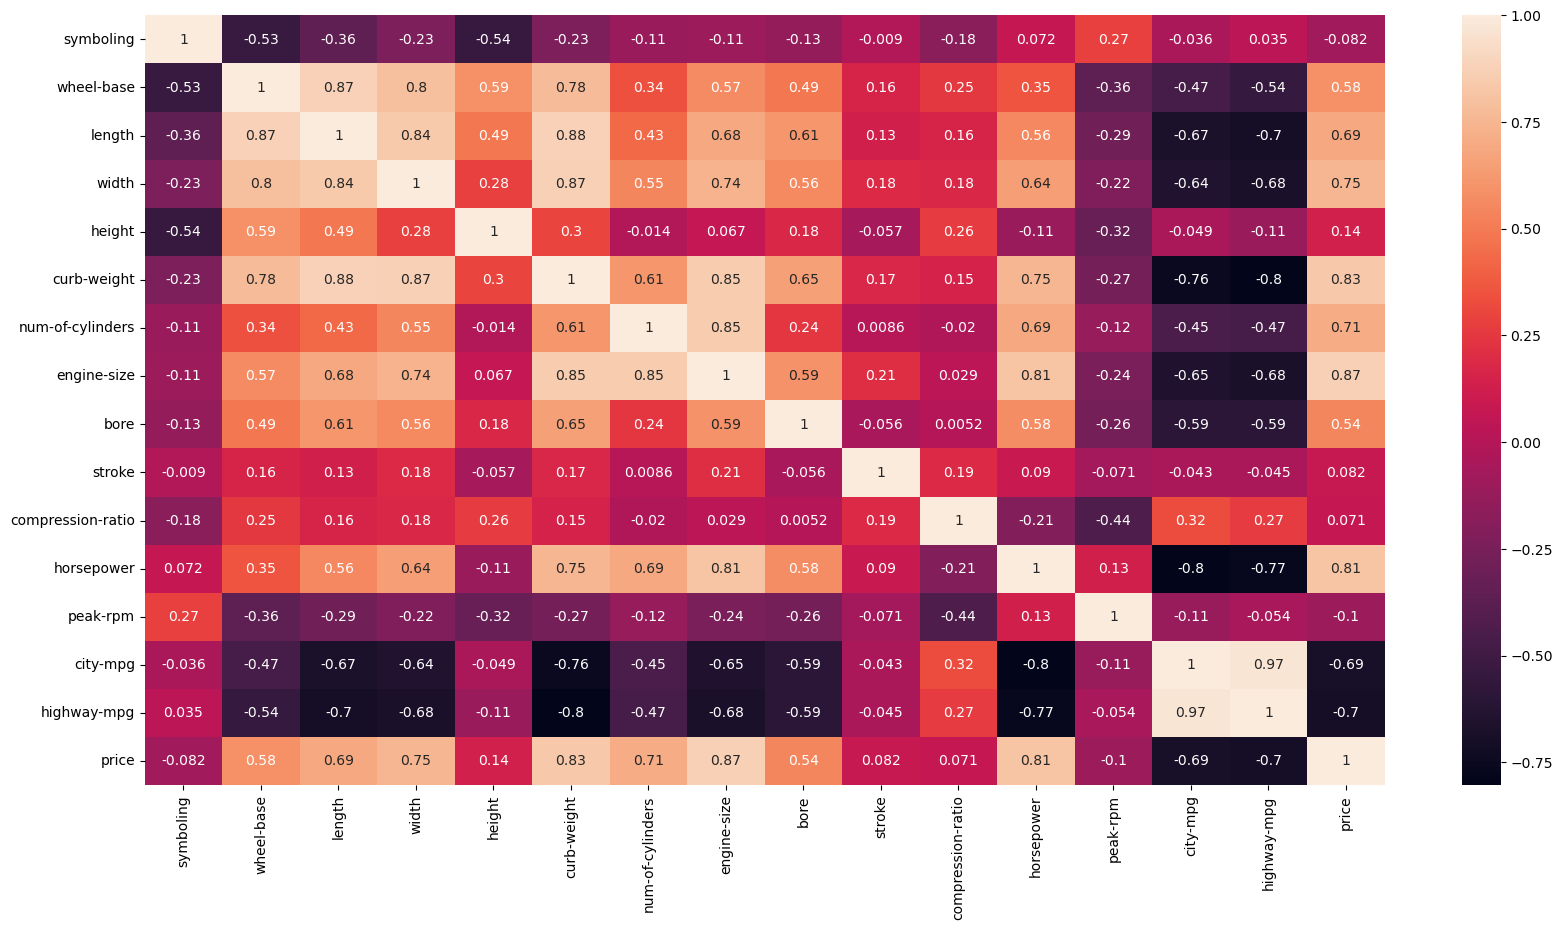

In [43]:
plt.figure(figsize = (20,10))
sns.heatmap(df.corr(),annot = True)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   wheel-base         205 non-null    float64
 2   length             205 non-null    float64
 3   width              205 non-null    float64
 4   height             205 non-null    float64
 5   curb-weight        205 non-null    int64  
 6   num-of-cylinders   205 non-null    int64  
 7   engine-size        205 non-null    int64  
 8   bore               201 non-null    float64
 9   stroke             201 non-null    float64
 10  compression-ratio  205 non-null    float64
 11  horsepower         203 non-null    float64
 12  peak-rpm           203 non-null    float64
 13  city-mpg           205 non-null    int64  
 14  highway-mpg        205 non-null    int64  
 15  price              201 non-null    float64
dtypes: float64(10), int64(6)
m

In [55]:
df.drop(['symboling','height','compression-ratio','stroke', 'peak-rpm'], axis=1, inplace = True)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   wheel-base        205 non-null    float64
 1   length            205 non-null    float64
 2   width             205 non-null    float64
 3   curb-weight       205 non-null    int64  
 4   num-of-cylinders  205 non-null    int64  
 5   engine-size       205 non-null    int64  
 6   bore              201 non-null    float64
 7   horsepower        203 non-null    float64
 8   city-mpg          205 non-null    int64  
 9   highway-mpg       205 non-null    int64  
 10  price             201 non-null    float64
dtypes: float64(6), int64(5)
memory usage: 17.7 KB


In [58]:
df['bore'] = df['bore'].fillna(df['bore'].median())
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())
df['price'] = df['price'].fillna(df['price'].median())

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   wheel-base        205 non-null    float64
 1   length            205 non-null    float64
 2   width             205 non-null    float64
 3   curb-weight       205 non-null    int64  
 4   num-of-cylinders  205 non-null    int64  
 5   engine-size       205 non-null    int64  
 6   bore              205 non-null    float64
 7   horsepower        205 non-null    float64
 8   city-mpg          205 non-null    int64  
 9   highway-mpg       205 non-null    int64  
 10  price             205 non-null    float64
dtypes: float64(6), int64(5)
memory usage: 17.7 KB


In [60]:
df.isna().sum()

wheel-base          0
length              0
width               0
curb-weight         0
num-of-cylinders    0
engine-size         0
bore                0
horsepower          0
city-mpg            0
highway-mpg         0
price               0
dtype: int64

In [61]:
df

,wheel-base,length,width,curb-weight,num-of-cylinders,engine-size,bore,horsepower,city-mpg,highway-mpg,price
0,88.6,168.8,64.1,2548,4,130,3.47,111.0,21,27,13495.0
1,88.6,168.8,64.1,2548,4,130,3.47,111.0,21,27,16500.0
2,94.5,171.2,65.5,2823,6,152,2.68,154.0,19,26,16500.0
3,99.8,176.6,66.2,2337,4,109,3.19,102.0,24,30,13950.0
4,99.4,176.6,66.4,2824,5,136,3.19,115.0,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...
200,109.1,188.8,68.9,2952,4,141,3.78,114.0,23,28,16845.0
201,109.1,188.8,68.8,3049,4,141,3.78,160.0,19,25,19045.0
202,109.1,188.8,68.9,3012,6,173,3.58,134.0,18,23,21485.0
203,109.1,188.8,68.9,3217,6,145,3.01,106.0,26,27,22470.0


In [62]:
df.describe()

,wheel-base,length,width,curb-weight,num-of-cylinders,engine-size,bore,horsepower,city-mpg,highway-mpg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,98.756585,174.049268,65.907805,2555.565854,4.380488,126.907317,3.329366,104.165854,25.219512,30.751220,13150.307317
std,6.021776,12.337289,2.145204,520.680204,1.080854,41.642693,0.270858,39.529733,6.542142,6.886443,7879.121326
min,86.600000,141.100000,60.300000,1488.000000,2.000000,61.000000,2.540000,48.000000,13.000000,16.000000,5118.000000
25%,94.500000,166.300000,64.100000,2145.000000,4.000000,97.000000,3.150000,70.000000,19.000000,25.000000,7788.000000
50%,97.000000,173.200000,65.500000,2414.000000,4.000000,120.000000,3.310000,95.000000,24.000000,30.000000,10295.000000
75%,102.400000,183.100000,66.900000,2935.000000,4.000000,141.000000,3.580000,116.000000,30.000000,34.000000,16500.000000
max,120.900000,208.100000,72.300000,4066.000000,12.000000,326.000000,3.940000,288.000000,49.000000,54.000000,45400.000000


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   wheel-base        205 non-null    float64
 1   length            205 non-null    float64
 2   width             205 non-null    float64
 3   curb-weight       205 non-null    int64  
 4   num-of-cylinders  205 non-null    int64  
 5   engine-size       205 non-null    int64  
 6   bore              205 non-null    float64
 7   horsepower        205 non-null    float64
 8   city-mpg          205 non-null    int64  
 9   highway-mpg       205 non-null    int64  
 10  price             205 non-null    float64
dtypes: float64(6), int64(5)
memory usage: 17.7 KB


### Train and Test Data

In [64]:
X = df.drop(["price"], axis = 1)   #input
y = df['price']   #output

In [65]:
X

,wheel-base,length,width,curb-weight,num-of-cylinders,engine-size,bore,horsepower,city-mpg,highway-mpg
0,88.6,168.8,64.1,2548,4,130,3.47,111.0,21,27
1,88.6,168.8,64.1,2548,4,130,3.47,111.0,21,27
2,94.5,171.2,65.5,2823,6,152,2.68,154.0,19,26
3,99.8,176.6,66.2,2337,4,109,3.19,102.0,24,30
4,99.4,176.6,66.4,2824,5,136,3.19,115.0,18,22
...,...,...,...,...,...,...,...,...,...,...
200,109.1,188.8,68.9,2952,4,141,3.78,114.0,23,28
201,109.1,188.8,68.8,3049,4,141,3.78,160.0,19,25
202,109.1,188.8,68.9,3012,6,173,3.58,134.0,18,23
203,109.1,188.8,68.9,3217,6,145,3.01,106.0,26,27


In [66]:
y

0      13495.0
1      16500.0
2      16500.0
3      13950.0
4      17450.0
        ...   
200    16845.0
201    19045.0
202    21485.0
203    22470.0
204    22625.0
Name: price, Length: 205, dtype: float64

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
X_train.shape

(164, 10)

In [84]:
X_train

,wheel-base,length,width,curb-weight,num-of-cylinders,engine-size,bore,horsepower,city-mpg,highway-mpg
66,104.9,175.0,66.1,2700,4,134,3.43,72.0,31,39
111,107.9,186.7,68.4,3075,4,120,3.46,95.0,19,24
153,95.7,169.7,63.6,2280,4,92,3.05,62.0,31,37
96,94.5,165.3,63.8,1971,4,97,3.15,69.0,31,37
38,96.5,167.5,65.2,2289,4,110,3.15,86.0,27,33
...,...,...,...,...,...,...,...,...,...,...
106,99.2,178.5,67.9,3139,6,181,3.43,160.0,19,25
14,103.5,189.0,66.9,3055,6,164,3.31,121.0,20,25
92,94.5,165.3,63.8,1938,4,97,3.15,69.0,31,37
179,102.9,183.5,67.7,3016,6,171,3.27,161.0,19,24


In [85]:
y_train.shape

(164,)

In [86]:
X_test.shape

(41, 10)

### Model Training

In [87]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

### Evaluation

In [88]:
y_pred = linear_model.predict(X_test)
y_pred   #predicted

array([25913.54215213, 17489.70371026, 11324.27879903, 13332.43787061,
       23633.37506756,  6823.7936628 ,  6562.48988603,  7748.91552735,
        9657.28121122,  6161.09784784, 16018.51276143,  7752.5330098 ,
       15198.78312964, 12501.01015617, 40252.56887695,  5904.09768372,
       -1877.85840222, 18988.99826392, 11895.84413805,  9303.25540287,
       12175.76119485, 21778.8959709 ,  6724.42965932,  2584.81407572,
        5967.52288903, 26496.30972703, 15454.99720341, 16033.42173396,
        6946.60362273, 15896.58742926, 23369.80079212,  5942.84785048,
        7604.25538832, 20603.778467  ,  9130.90437202, 23255.92442931,
       10356.80073513,  9073.0189973 ,  4695.63883762, 19064.70634619,
        9059.56602188])

In [89]:
y_test   #actual

15     30760.0
9      10295.0
100     9549.0
132    11850.0
68     28248.0
95      7799.0
159     7788.0
162     9258.0
147    10198.0
182     7775.0
191    13295.0
164     8238.0
65     18280.0
175     9988.0
73     40960.0
152     6488.0
18      5151.0
82     12629.0
86      8189.0
143     9960.0
60      8495.0
101    13499.0
98      8249.0
30      6479.0
25      6692.0
16     41315.0
168     9639.0
195    13415.0
97      7999.0
194    12940.0
67     25552.0
120     6229.0
154     7898.0
202    21485.0
79      7689.0
69     28176.0
145    11259.0
55     10945.0
45     10295.0
84     14489.0
146     7463.0
Name: price, dtype: float64

In [90]:
mse = mean_squared_error(y_test, y_pred)
mse

17054794.481144227

In [91]:
mae = mean_absolute_error(y_test, y_pred)
mae

3013.2196450030265

In [92]:
r2_score(y_test, y_pred)   #accuracy

0.7825847410805423

### Assumptions

In [93]:
# Assumption of residual
df_residual = pd.DataFrame()
df_residual['Residual'] = y_test - y_pred

<Axes: xlabel='Residual', ylabel='Density'>

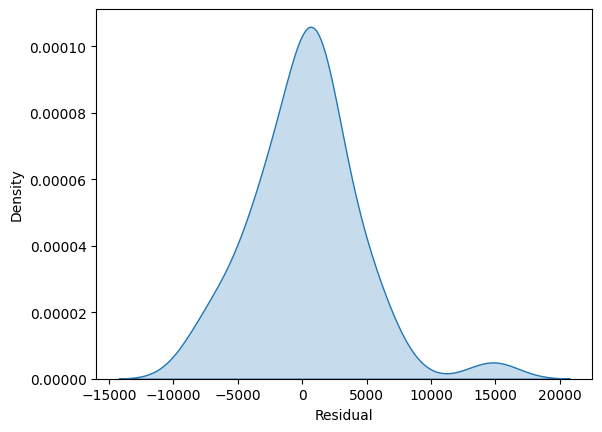

In [94]:
sns.kdeplot(df_residual['Residual'], fill=True)

<Axes: ylabel='Residual'>

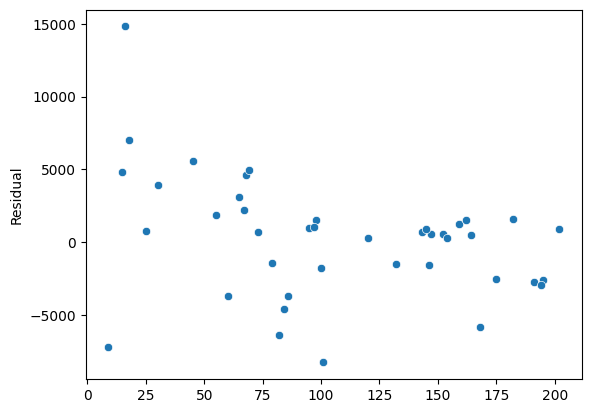

In [95]:
# Assumption of Homoscadasticity
sns.scatterplot(df_residual['Residual'])

## ***************************

In [96]:
import pickle

In [97]:
with open("auto_price_model.pkl", "wb") as file:
    pickle.dump(linear_model, file)
print("Model saved successfully!")

Model saved successfully!


### Load Pickle File & Predict Price

In [98]:
# Load saved model
with open("auto_price_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

# Example input (engine_size, horsepower, curb_weight, highway_mpg)
new_data = np.array([[88.6,168.8,64.1,2548,4,130,3.47,111.0,21,27]])

# Predict price
predicted_price = loaded_model.predict(new_data)

print("Predicted Car Price:", predicted_price[0])


Predicted Car Price: 13619.662718275085


C:\Users\Chandrashekhar\anaconda3\envs\venv\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
